# Proyek Analisis Data: E-commerce publik dataset
- **Nama:** Sandi Gunawan
- **Email:** cdcc277d6y1864@student.devacademy.id
- **ID Dicoding:** CDCC277D6Y1864

## Menentukan Pertanyaan Bisnis

- Kategori produk yang mana yang memberikan kontribusi revenue terbesar?
- Wilayah yang mana dengan penjualan tertinggi?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import os
import pickle
import folium

## Data Wrangling

### Gathering Data

In [2]:

# Buat folder lokal
os.makedirs("data", exist_ok=True)

# Fungsi download dari GDrive
def download_file(file_id, output_name):
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, output_name, quiet=False)

# Masukkin FILE_ID SETIAP DATA
download_file("1d_W4-U7cx5GUzdzAV4zCokHBIvnfftsb", "data/customers_dataset.csv")
download_file("18Y2g-HCPGKHLxWz5AJpNSTndl8sUlBne", "data/geolocation_dataset.csv")
download_file("1zdM8OD0k4KgebM1WAWK7O4Nv-mjFHfvi", "data/order_items_dataset.csv")
download_file("15Afi-jf1umsUnUuC-a3mdFd6xOSKlSzQ", "data/orders_dataset.csv")
download_file("1sKDTG6SjMZWQ937Sd7KoMv3LJ4gME5YW", "data/product_category_name_translation.csv")
download_file("1fZuY6ncS2rLfrylKbjN8s7IlngynFhLY", "data/products_dataset.csv")

#LOAD SEMUA DATASET
customer = pd.read_csv("data/customers_dataset.csv")
geolocation = pd.read_csv("data/geolocation_dataset.csv")
order_items = pd.read_csv("data/order_items_dataset.csv")
orders = pd.read_csv("data/orders_dataset.csv")
product_category_name_translation = pd.read_csv("data/product_category_name_translation.csv")
product = pd.read_csv("data/products_dataset.csv")


Downloading...
From: https://drive.google.com/uc?id=1d_W4-U7cx5GUzdzAV4zCokHBIvnfftsb
To: /content/data/customers_dataset.csv
100%|██████████| 9.03M/9.03M [00:00<00:00, 23.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=18Y2g-HCPGKHLxWz5AJpNSTndl8sUlBne
To: /content/data/geolocation_dataset.csv
100%|██████████| 61.3M/61.3M [00:00<00:00, 64.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zdM8OD0k4KgebM1WAWK7O4Nv-mjFHfvi
To: /content/data/order_items_dataset.csv
100%|██████████| 15.4M/15.4M [00:00<00:00, 37.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=15Afi-jf1umsUnUuC-a3mdFd6xOSKlSzQ
To: /content/data/orders_dataset.csv
100%|██████████| 17.7M/17.7M [00:00<00:00, 40.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sKDTG6SjMZWQ937Sd7KoMv3LJ4gME5YW
To: /content/data/product_category_name_translation.csv
100%|██████████| 2.61k/2.61k [00:00<00:00, 10.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fZuY6ncS2rLfrylKbjN8s7IlngynFhLY
To

DATA ANALISIS REVENUE

In [3]:

#Merge Data
df_revenue = (
    order_items
    .merge(product, on="product_id", how="left")
    .merge(product_category_name_translation, on="product_category_name", how="left")
)

df_revenue.head()



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


DATA ANALISIS GEOLOCATION

In [4]:
#Agregasi agar tidak terlalu banyak baris
geo = (
    geolocation
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean")
    )
)

#MERGE
df_geo= (
      order_items
    .merge(orders, on="order_id", how="left")
    .merge(customer, on="customer_id", how="left")
    .merge(geo,
           left_on="customer_zip_code_prefix",
           right_on="geolocation_zip_code_prefix",
           how="left")
)

df_geo.head()



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,28013.0,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,15775.0,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,35661.0,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,12952.0,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,13226.0,-23.243402,-46.827614


**Insight:**
- Dataset sudah dimerge sesuai dengan kebutuhan analisis.
- Variabel penting untuk analisis revenue dan wilayah sudah tersedia karna hasil merge tadi.


### Assessing Data

CEK DATA REVENUE

1. Mengecek struktur & tipe data

In [5]:
df_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product_category_name          111047 non-null  object 
 8   product_name_lenght            111047 non-null  float64
 9   product_description_lenght     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

2. Mencari missing values

In [6]:
df_revenue.isnull().sum().sort_values(ascending=False)

,0
product_category_name_english,1627
product_category_name,1603
product_name_lenght,1603
product_photos_qty,1603
product_description_lenght,1603
product_height_cm,18
product_length_cm,18
product_weight_g,18
product_width_cm,18
freight_value,0


3. Mengecek parameter statistik

In [7]:
df_revenue.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000
mean,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546
std,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


4. Mengecek duplikasi data

In [8]:
df_revenue.duplicated().sum()

np.int64(0)

5. Memastikan tidak ada data explosion

In [9]:
df_revenue["order_id"].nunique()

98666

CEK DATA GEOLOCATION

1. Mengecek struktru data & tipe data

In [10]:
df_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  object 
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_customer_date 

2. Mencari missing values

In [11]:
df_geo.isnull().sum().sort_values(ascending=False)

,0
order_delivered_customer_date,2454
order_delivered_carrier_date,1194
geolocation_lng,302
geolocation_lat,302
geolocation_zip_code_prefix,302
order_approved_at,15
shipping_limit_date,0
product_id,0
order_item_id,0
order_id,0


3. Mengecek parameter statistik

In [12]:
df_geo.describe()

,order_item_id,price,freight_value,customer_zip_code_prefix,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,112650.000000,112650.000000,112650.000000,112650.000000,112348.000000,112348.000000,112348.000000
mean,1.197834,120.653739,19.990320,35119.309090,35042.482652,-21.233540,-46.201855
std,0.705124,183.633928,15.806405,29866.120801,29853.323545,5.570373,4.037734
min,1.000000,0.850000,0.000000,1003.000000,1003.000000,-33.689948,-72.668881
25%,1.000000,39.900000,13.080000,11310.000000,11250.000000,-23.591275,-48.112804
50%,1.000000,74.990000,16.260000,24340.000000,24240.000000,-22.929564,-46.633932
75%,1.000000,134.900000,21.150000,59028.750000,58430.250000,-20.171978,-43.635297
max,21.000000,6735.000000,409.680000,99990.000000,99990.000000,42.184003,-8.723762


4. Mengecek duplikasi data

In [13]:
df_geo.duplicated().sum()

np.int64(0)

5. Mengecek tidak adanya data explosion

In [14]:
df_geo["order_id"].nunique()

98666

**Insight:**
- Data Revenue:
  - Dataset berada di level item per order, bukan order. Karena unique order_id: 98,666 sedangkan total barisnya:112,650, alhasil satu order bisa punya lebih dari 1 item.
  - Merge data berhasil tanpa adanya data explosion, dengan duplicated data yang 0 dan jumlah baris yang masih wajar karena tidak ada data yang double.
  - Terdapat gap pada metadata produk. Tidak semua produk memiliki kategori/deskripsi. Hal ini diperkuat dengan 1627 missing values yang ada di product_category_name_english.
  - Missing bersifat terstruktur, bukan random. Missing terlihat hanya terjadi pada kolom produk dan tidak terjadi pada price/order. Beberapa atribut produk didapatkan 1603 missing values.
  - Terlihat juga pada dimensi produk terdapat 18 missing values.
  - Distribusi harga juga right-skewed. Mayoritas produk harganya murah dan terdapat juga sedikit produk yang sangat mahal (outlier).
  - Ongkir pada data tersebut sekitar 16-17% dari harga produk.
  - Dimensi produk di sini juga bervariasi. Dari kecil ke sangat besar.
  - Mayoritas dari order itu 1 item.
- Data Wilayah:
  - Data masih berada di level item per order, bukan per wilayah langsung. Artinya, satu wilayah bisa muncul berkali-kali, karena bisa saja satu order lebih dari 1 item dan satu customer lebih dari 1 order.
  - Merge data berhasil tanpa adanya data explosion
  - Terdapat 2545 missing values pada order_delivered_customer_date. Artinya, tidak semua order berhasil sampai ke tahap delivery.
  - Terdapat 1194 missing values pada order_delivered_carrier_date. Artinya, tidak semua order masuk ke tahap pengiriman oleh kurir.
  - Terdapat 302 missing values pada geolocation_lat/lng. Artinya, sekitar 302 data tidak punya titik koordinat lokasi. Alhasil tidak semua customer dipetakan ke lokasi geografis.
  - Terdapat 15 missing values pada order_approved_at. Artinya, hampir semua order berhasil melewati tahap approval.
  - Pola revenue di data wilayah sama dengan data produk (skewed). Artinya, wilayah dengan revenue tinggi bisa saja dipengaruhi oleh sedikitnya transaksi mahal pada wilayah tersebut.
  - Tidak ada duplikasi data dan missing values pada kolom utama (price, order_id, customer_id).

### Cleaning Data

Cleaning Data Revenue

In [15]:
#Copy Data Awal
df_revenue_clean = df_revenue.copy()

#Missing kategori
df_revenue_clean["product_category_name_english"] = (
    df_revenue_clean["product_category_name_english"]
    .fillna("unknown")
)

#Outlier harga
q1 = df_revenue_clean["price"].quantile(0.25)
q3 = df_revenue_clean["price"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

df_revenue_clean = df_revenue_clean[df_revenue_clean["price"] <= upper_bound]

#Konsistensi harga
df_revenue_clean[df_revenue_clean["price"] <= 0]

#Tipe data
df_revenue_clean["shipping_limit_date"] = pd.to_datetime(
    df_revenue_clean["shipping_limit_date"]
    )

#Reduksi kolom
df_revenue_clean = df_revenue_clean.drop(columns=[
    "product_name_lenght",
    "product_description_lenght"
], errors="ignore")

df_revenue_clean.info()
df_revenue_clean.isnull().sum().sort_values(ascending=False)




<class 'pandas.core.frame.DataFrame'>
Index: 104223 entries, 0 to 112649
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       104223 non-null  object        
 1   order_item_id                  104223 non-null  int64         
 2   product_id                     104223 non-null  object        
 3   seller_id                      104223 non-null  object        
 4   shipping_limit_date            104223 non-null  datetime64[ns]
 5   price                          104223 non-null  float64       
 6   freight_value                  104223 non-null  float64       
 7   product_category_name          102703 non-null  object        
 8   product_photos_qty             102703 non-null  float64       
 9   product_weight_g               104206 non-null  float64       
 10  product_length_cm              104206 non-null  float64       
 11  produ

,0
product_photos_qty,1520
product_category_name,1520
product_length_cm,17
product_weight_g,17
product_height_cm,17
product_width_cm,17
price,0
shipping_limit_date,0
seller_id,0
product_id,0


Cleaning Data Geolocation

In [16]:
#Filter order yang sesuai
df_geo_clean = df_geo[df_geo["order_status"] == "delivered"].copy()

#Missing geolocation
df_geo_clean = df_geo_clean.dropna(subset=["geolocation_lat", "geolocation_lng"])

#Konversi tipe waktu
df_geo_clean["order_purchase_timestamp"] = pd.to_datetime(df_geo_clean["order_purchase_timestamp"])
df_geo_clean["order_delivered_customer_date"] = pd.to_datetime(df_geo_clean["order_delivered_customer_date"])

#Validasi nilai revenue
df_geo_clean = df_geo_clean[df_geo_clean["price"] > 0]

#Reduksi kolom
df_geo_clean = df_geo_clean[[
    "order_id",
    "price",
    "freight_value",
    "customer_city",
    "customer_state",
    "geolocation_lat",
    "geolocation_lng",
    "order_purchase_timestamp"
]]
df_geo_clean.info()
df_geo_clean.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
Index: 109909 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  109909 non-null  object        
 1   price                     109909 non-null  float64       
 2   freight_value             109909 non-null  float64       
 3   customer_city             109909 non-null  object        
 4   customer_state            109909 non-null  object        
 5   geolocation_lat           109909 non-null  float64       
 6   geolocation_lng           109909 non-null  float64       
 7   order_purchase_timestamp  109909 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 7.5+ MB


,0
order_id,0
price,0
freight_value,0
customer_city,0
customer_state,0
geolocation_lat,0
geolocation_lng,0
order_purchase_timestamp,0


**Insight:**
- Data Revenue:
  - Setelah melakukan cleaning, baris sekarang tersisa 104,223 yang sebelumnya sekitar 112k. Missing kategori masih ada tetapi relatif kecil.
  - Terdapat produk dengan metadata tidak lengkap. Banyak yang tidak mengisi dimensi item, sekitar 17 data.
  - Tidak semua missing values bisa diimputasi, seperti foto dan deskripsi item.
- Data wilayah
  - Sudah tidak ada missing values
  - Ukuran data masih sekitar 109k baris, lebih ideal dibanding sebelum diclean.

## Exploratory Data Analysis (EDA)

### Explore Data Revenue

 Revenue per Category

In [17]:
revenue_category = (
    df_revenue_clean
    .groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        total_items=("order_item_id", "count"),
        avg_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

revenue_category.head(10)

,total_revenue,total_items,avg_price
product_category_name_english,,,
bed_bath_table,944030.60,10912,86.513068
sports_leisure,717240.40,8156,87.940216
health_beauty,677634.72,8513,79.599991
computers_accessories,676062.80,7450,90.746685
furniture_decor,620180.24,8059,76.954987
watches_gifts,583947.53,5016,116.416972
housewares,479914.48,6652,72.145893
cool_stuff,405413.94,3406,119.029342
auto,339081.66,3810,88.997811


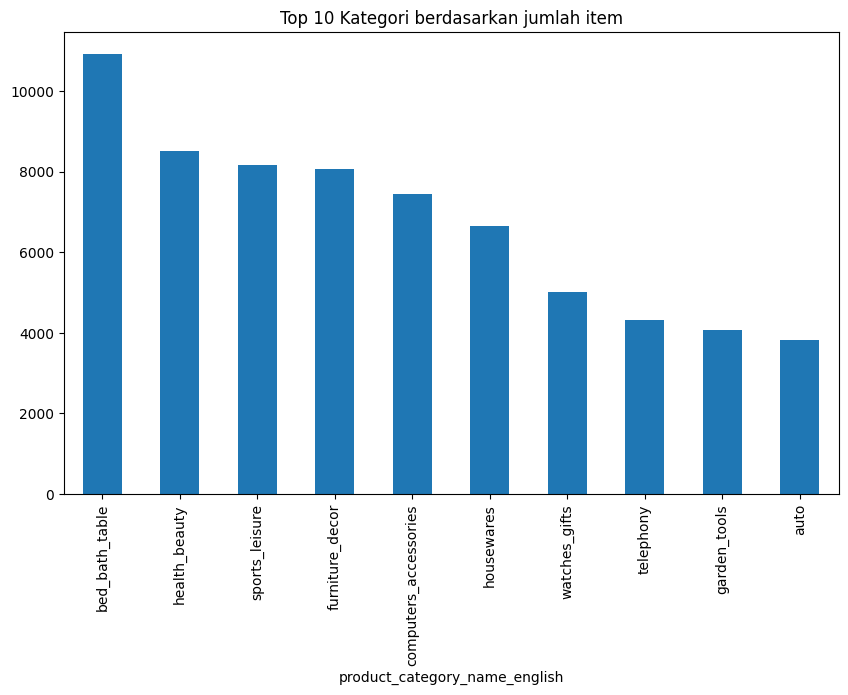

In [18]:
category_count = df_revenue_clean["product_category_name_english"].value_counts().head(10)

plt.figure(figsize=(10,6))
category_count.plot(kind="bar")
plt.title("Top 10 Kategori berdasarkan jumlah item")
plt.show()

Top Category vs Bottom Category

In [19]:
revenue_category.tail(10)

,total_revenue,total_items,avg_price
product_category_name_english,,,
dvds_blu_ray,2051.39,60,34.189833
la_cuisine,1665.99,13,128.153077
diapers_and_hygiene,1567.59,39,40.194615
arts_and_craftmanship,1524.52,23,66.283478
flowers,1110.04,33,33.637576
home_comfort_2,760.27,30,25.342333
cds_dvds_musicals,730.00,14,52.142857
fashion_childrens_clothes,569.85,8,71.231250
security_and_services,283.29,2,141.645000


Distribusi harga

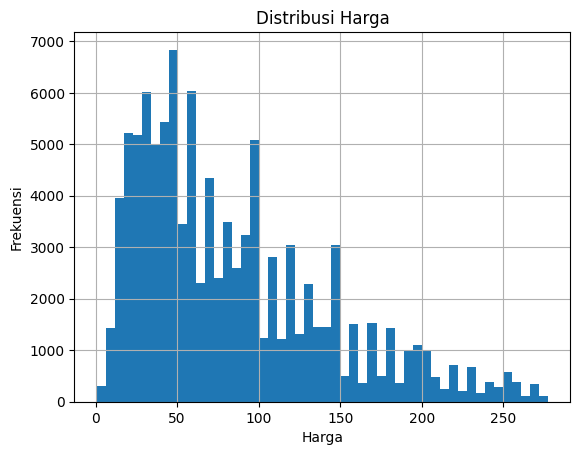

In [20]:
df_revenue_clean["price"].hist(bins=50)
plt.title("Distribusi Harga")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")
plt.show()

Boxplot Harga Produk

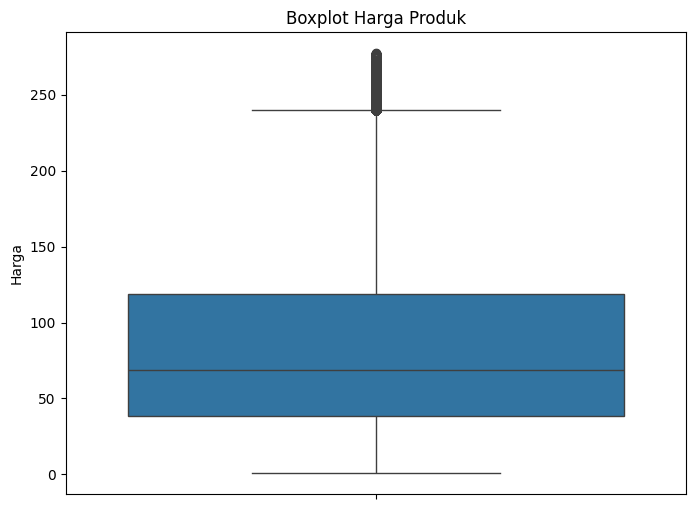

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_revenue_clean["price"])
plt.title("Boxplot Harga Produk")
plt.ylabel("Harga")
plt.show()

Kategori dengan Harga Rata-Rata Tertinggi

In [22]:
df_revenue_clean.groupby("product_category_name_english")["price"].mean().sort_values(ascending=False).head(10)



,price
product_category_name_english,
home_appliances_2,148.688433
furniture_bedroom,147.987158
office_furniture,142.218538
security_and_services,141.645000
la_cuisine,128.153077
air_conditioning,123.939294
cool_stuff,119.029342
watches_gifts,116.416972
home_confort,112.512850


Volume vs Revenue

In [23]:
df_revenue_clean.groupby("product_category_name_english").agg(
    total_revenue=("price", "sum"),
    total_items=("order_item_id", "count")
).sort_values("total_revenue", ascending=False).head(10)


,total_revenue,total_items
product_category_name_english,,
bed_bath_table,944030.60,10912
sports_leisure,717240.40,8156
health_beauty,677634.72,8513
computers_accessories,676062.80,7450
furniture_decor,620180.24,8059
watches_gifts,583947.53,5016
housewares,479914.48,6652
cool_stuff,405413.94,3406
auto,339081.66,3810


Freight vs Price

In [24]:
df_revenue_clean[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.340517
freight_value,0.340517,1.000000


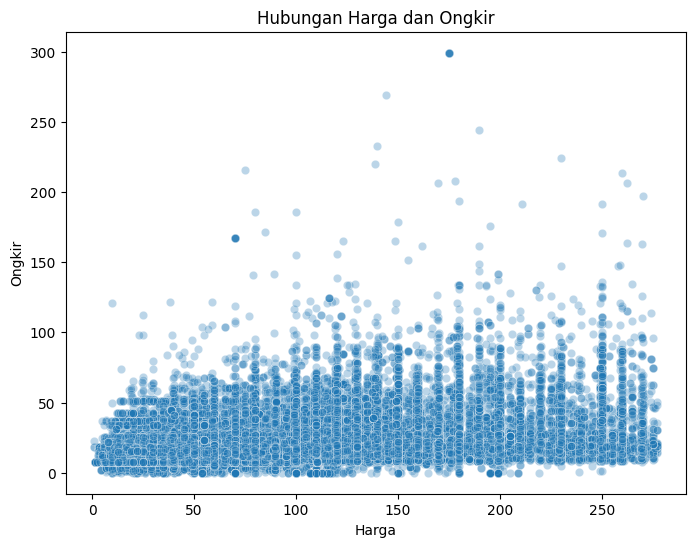

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_revenue_clean["price"],
    y=df_revenue_clean["freight_value"],
    alpha=0.3
)
plt.title("Hubungan Harga dan Ongkir")
plt.xlabel("Harga")
plt.ylabel("Ongkir")
plt.show()


### Explore Data Geolocation

 Revenue per State

In [26]:
revenue_state = (
    df_geo_clean
    .groupby("customer_state")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

revenue_state.head(10)

,total_revenue,total_orders
customer_state,,
SP,5065820.02,40487
RJ,1758005.01,12337
MG,1551718.06,11345
RS,728648.93,5341
PR,665378.58,4912
SC,507012.13,3546
BA,492582.58,3248
GO,282293.04,1948
DF,273069.61,1917


Revenue per City

In [27]:
revenue_city = (
    df_geo_clean
    .groupby("customer_city")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)
revenue_city.head(10)

,total_revenue,total_orders
customer_city,,
sao paulo,1859232.31,15043
rio de janeiro,955573.97,6601
belo horizonte,346039.04,2697
brasilia,272385.92,1908
curitiba,205999.33,1489
campinas,184657.87,1406
porto alegre,182319.55,1342
salvador,172817.26,1185
guarulhos,139008.19,1144


 Average Order Value (AOV)

In [28]:
aov_state = (
    df_geo_clean
    .groupby("customer_state")
    .agg(
        tavg_order_value= ("price", "mean")
    )
    .sort_values("tavg_order_value", ascending=False)
)
aov_state.head(10)


,tavg_order_value
customer_state,
PB,190.527089
AL,184.802183
AC,175.065604
RO,167.870701
PA,165.504468
AP,165.121111
PI,161.861731
RN,157.768324
TO,156.059935


 Distribusi Revenue

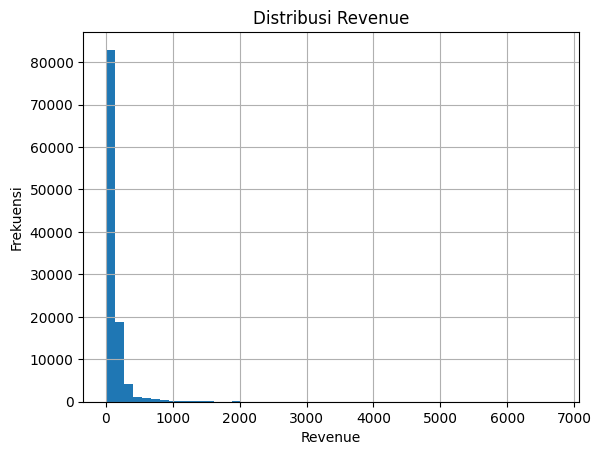

In [29]:
df_geo_clean["price"].hist(bins=50)
plt.title("Distribusi Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frekuensi")
plt.show()

Distribusi lokasi

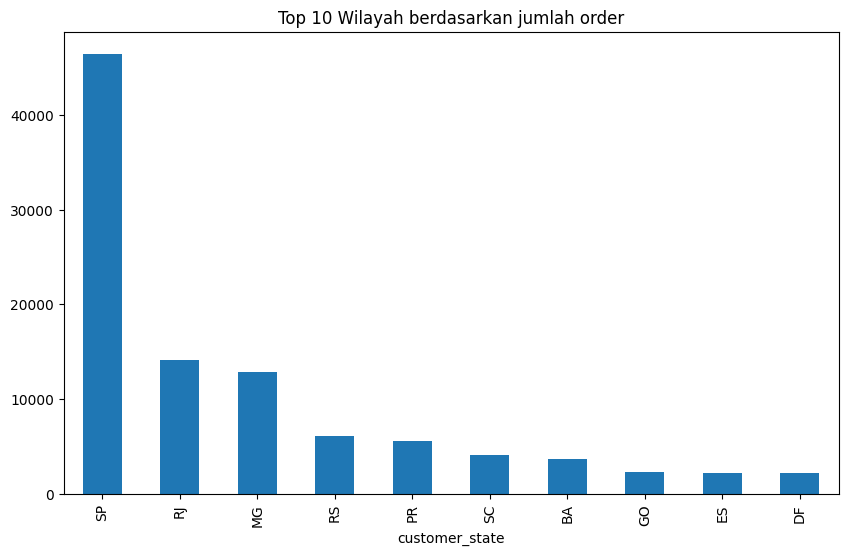

In [30]:
state_count = df_geo_clean["customer_state"].value_counts().head(10)

plt.figure(figsize=(10,6))
state_count.plot(kind="bar")
plt.title("Top 10 Wilayah berdasarkan jumlah order")
plt.show()

Scatter lokasi (lat vs lng)

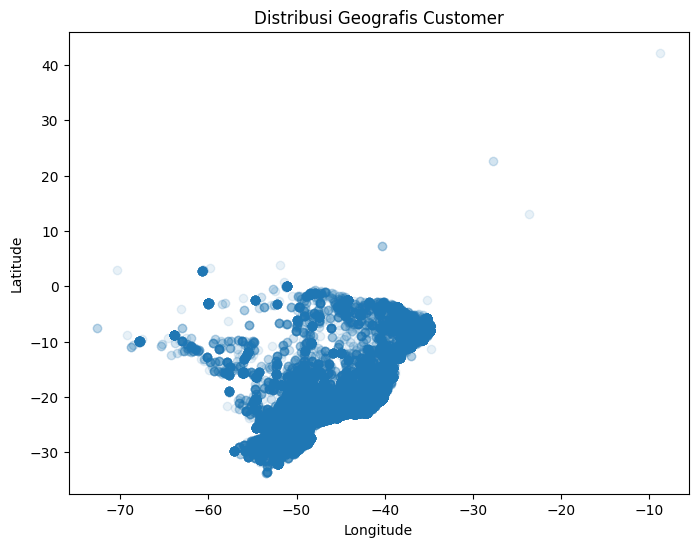

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_geo_clean["geolocation_lng"],
    df_geo_clean["geolocation_lat"],
    alpha=0.1
)
plt.title("Distribusi Geografis Customer")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


 Revenue + Freight

In [32]:
freight_analysis = (
    df_geo_clean
    .groupby("customer_state")
    .agg(
        avg_revenue=("price", "mean"),
        avg_freight=("freight_value", "mean")
    )
)
freight_analysis.head(10)

,avg_revenue,avg_freight
customer_state,,
AC,175.065604,40.047912
AL,184.802183,35.833662
AM,135.925399,33.310613
AP,165.121111,34.160494
BA,134.182125,26.469777
CE,154.080761,32.738993
DF,125.491549,21.062486
ES,120.896999,22.041735
GO,124.467831,22.576777


Insight
- Data Revenue\
  Dari data yang sudah di exploratory tadi, dapat disimpulkan bahwa distribusi harga produk bersifat tidak normal dengan kecenderungan right-skewed, mengindikasikan produk berharga rendah hingga menengah serta outlier pada harga tinggi lebih banyak. Akan tetapi, analisis kategori mengindikasikan bahwa total revenue lebih didorong oleh volume penjualan dibandingkan harga rata-rata, di mana kategori dengan jumlah item tinggi seperti bed_bath_table menjadi kategori utama, sedangkan kategori dengan harga tinggi tidak memberikan kontribusi signifikan terhadap revenue. Selain itu, tidak terlihat pula hubungan yang jelas antara harga produk dan ongkir. Hal ini mengindikasikan bahwa biaya pengiriman kemungkinan lebih dipengaruhi oleh karakteristik fisik produk daripada nilai ekonoominya.
- Data Geolocation\
  Berdasarkan exploratory tadi, dapat disimpulkan bahwa distribusi penjualan e-commerce sangat terpusat pada wilayah urban utama, dengan Sao Paolo sebagai kontributor utamanya, baik dari segi volume maupun reveneunya. Wilayah lain dengan kontribusi revenue yang jauh lebih kecil menunjukkan nilai transaksi rata-rata yang lebih tinggi, artinya ada segmentasi pasar berdasarkan karakteristik geografis. Variasi ongkir antar wilayah juga mengindikasikan adanya perbedaan efisiensi logistik, yang berpotensi mempengaruhi perilaku pembelian pelanggan.

###SIMPAN HASIL CLEANING KE PICKLE

In [33]:
df_revenue_clean.to_pickle('revenue_clean.pkl')
df_geo_clean.to_pickle('geo_clean.pkl')

## Visualization & Explanatory Analysis


### Pertanyaan 1: Kategori produk yang mana yang memberikan kontribusi revenue terbesar?

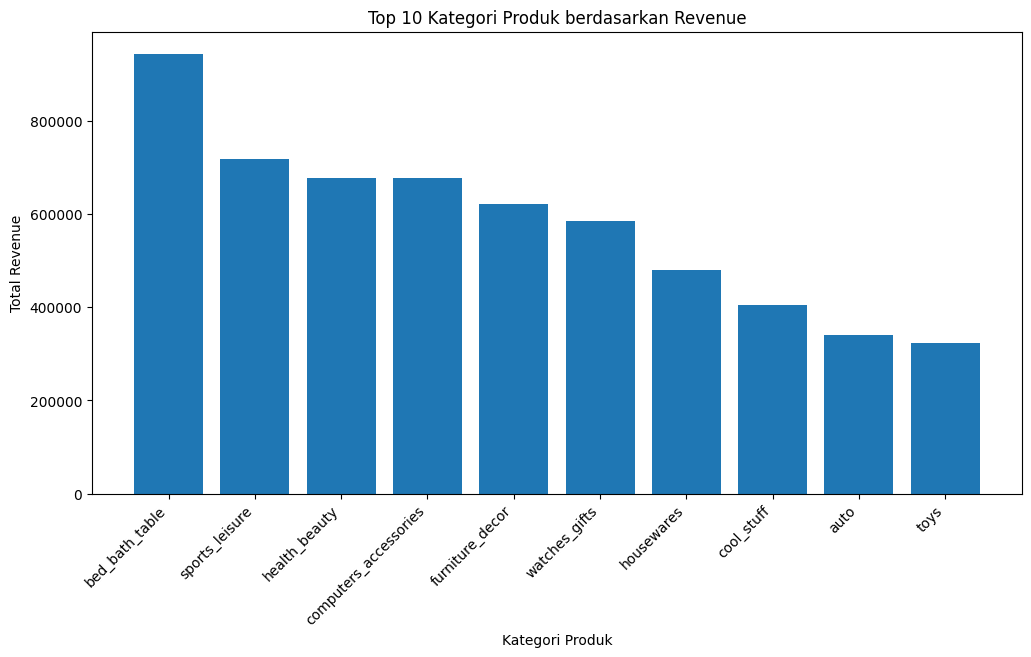

In [34]:
top10_revenue_category = revenue_category.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_revenue_category.index, top10_revenue_category["total_revenue"])
plt.xlabel("Kategori Produk")
plt.ylabel("Total Revenue")
plt.title("Top 10 Kategori Produk berdasarkan Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

In [35]:
revenue_category["revenue_share"]=(
    revenue_category["total_revenue"]/revenue_category["total_revenue"].sum()
)

revenue_category.sort_values("revenue_share", ascending=False).head(10)


,total_revenue,total_items,avg_price,revenue_share
product_category_name_english,,,,
bed_bath_table,944030.60,10912,86.513068,0.107863
sports_leisure,717240.40,8156,87.940216,0.081951
health_beauty,677634.72,8513,79.599991,0.077425
computers_accessories,676062.80,7450,90.746685,0.077246
furniture_decor,620180.24,8059,76.954987,0.070861
watches_gifts,583947.53,5016,116.416972,0.066721
housewares,479914.48,6652,72.145893,0.054834
cool_stuff,405413.94,3406,119.029342,0.046322
auto,339081.66,3810,88.997811,0.038743


Berdasarkan data yang sudah ditampilkan, kategori produk dengan kontribusi revenue terbesar adalah bed_bath_table, diikuti oleh sports_leisure dan health_beauty. Kategori bed_bath_table menempati posisi pertama karena jumlah item yang terjual sangat tinggi, meskipun harga rata-ratanya tidak termasuk yang tertinggi. Hal ini menunjukkan bahwa pada dataset ini, volume penjualan merupakan faktor utama dalam pembentukan revenue.

### Pertanyaan 2: Wilayah yang mana dengan penjualan tertinggi?

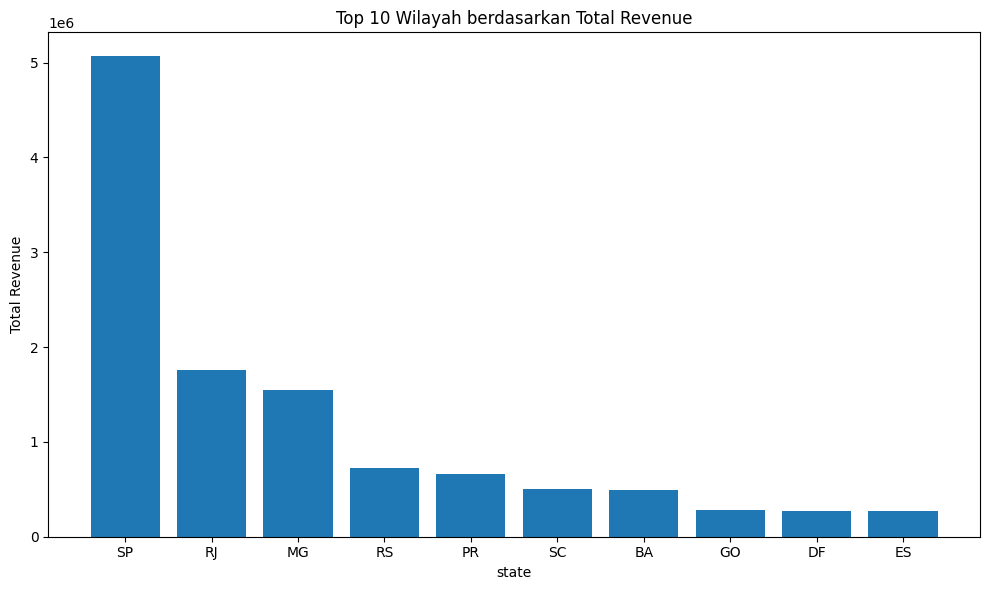

In [36]:
top10_state = revenue_state.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_state.index, top10_state["total_revenue"])
plt.xlabel("state")
plt.ylabel("Total Revenue")
plt.title("Top 10 Wilayah berdasarkan Total Revenue")
plt.tight_layout()
plt.show()

In [37]:
revenue_state["revenue_share"]=(
    revenue_state["total_revenue"]/revenue_state["total_revenue"].sum()
)

revenue_state.sort_values("revenue_share", ascending=False).head(10)


,total_revenue,total_orders,revenue_share
customer_state,,,
SP,5065820.02,40487,0.384191
RJ,1758005.01,12337,0.133327
MG,1551718.06,11345,0.117682
RS,728648.93,5341,0.055261
PR,665378.58,4912,0.050462
SC,507012.13,3546,0.038452
BA,492582.58,3248,0.037357
GO,282293.04,1948,0.021409
DF,273069.61,1917,0.020710


Pertanyaan "Wilayah yang mana dengan penjualan tertinggi?" sudah bisa dijawab sekarang. Terlihat dengan jelas bahwa wilayah SP (Sao Paolo) merupakan kontributor terbesar terhadap total revenue, dengan nilai yang secara signifikan lebih tinggi dibandingkan wilayah lainnya. Hal ini diikuti juga oleh jumlah order yang jauh lebih besar, yang mengindikasikan bahwa tingginya revenue di wilayah tersebut didorong oleh volume transaksi yang tinggi.\
\
Wilayah lain seperti RJ (Rio de Janeiro) dan MG (Minas Gerais) juga menunjukkan kontribusi yang cukup besar, tetapi masih berada di bawah SP (Sao Paolo). Hal ini menunjukkan bahwa adanya konsentrasi aktivitas e-commerce yang kuat pada wilayah tertentu, khususnya pada pusat-pusat ekonomi utama.

# Analisis Lanjutan

####PREPROCESSING
Data yang sudah di cleaning, kita gabungkan untuk nanti di analisis lanjutan. Dengan menggunakan library pickle, data cleaningnya dipanggil melalui pickle tanpa upload file lagi.


In [38]:
rev = pd.read_pickle("revenue_clean.pkl")
geo = pd.read_pickle("geo_clean.pkl")

df = pd.merge(rev, geo, on="order_id", how="inner")

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["total_value"] = df["price_x"] + df["freight_value_x"]

####RFM ANALYSIS
Pada tahap ini, tujuan kita yaitu mengukur perilaku aktivitas dan nilai ekonominya.

In [39]:
snapshot_date = df["order_purchase_timestamp"].max()

rfm = df.groupby("customer_city").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count",
    "total_value": "sum"
}).reset_index()

rfm.columns = ["city", "recency", "frequency", "monetary"]
rfm.sort_values("monetary", ascending=False).head(10)

,city,recency,frequency,monetary
3421,sao paulo,0,24257,2073702.63
2997,rio de janeiro,0,9912,1004945.91
430,belo horizonte,2,4046,369523.68
525,brasilia,6,2738,279296.35
2810,porto alegre,1,2142,235194.56
1086,curitiba,0,2422,234053.45
666,campinas,0,2120,190501.98
3088,salvador,7,1687,188382.20
1455,guarulhos,1,1653,153920.18
1374,goiania,6,1521,143687.88


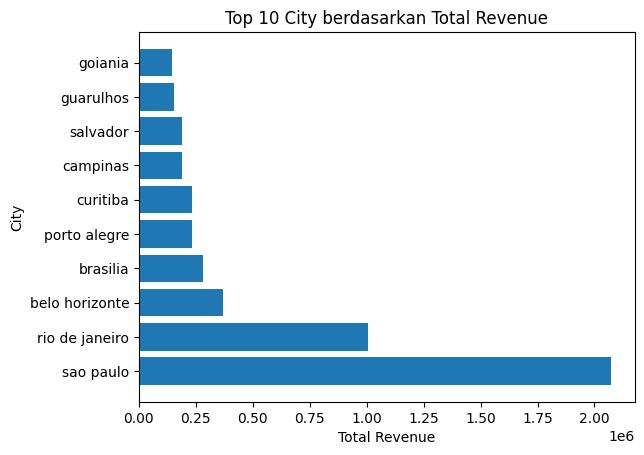

In [40]:
top_cities = rfm.sort_values("monetary", ascending=False).head(10)

plt.figure()
plt.barh(top_cities["city"], top_cities["monetary"])
plt.xlabel("Total Revenue")
plt.ylabel("City")
plt.title("Top 10 City berdasarkan Total Revenue")
plt.show()

Insight: Dilihat pada data di atas, sao paolo berada di urutan pertama. Terdapat korelasi juga antara monetary dan frequency, di mana semakin tinggi frequency maka monetary juga semakin tinggi.

####SCORING
Tujuan pada tahap ini adalah kita dapat melihat kategori seperi recency, frequency, dan monetary yang sudah disinggung di tahap sebelumnya menjadi sebuah score-score yang bisa dibandingkan.

In [41]:
rfm["R_score"] = pd.qcut(rfm["recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1,2,3,4])

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm.head()

,city,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,abadia dos dourados,58,3,413.50,3,2,2,322
1,abaete,8,11,1479.92,4,3,4,434
2,abaetetuba,25,19,3239.86,3,4,4,344
3,abaiara,110,2,332.15,2,2,2,222
4,abaira,23,2,203.00,4,2,2,422


Insight: Di sini menunjukkan bahwa nilai recency yang tinggi akan memiliki score yang rendah, artinya rentang waktu pembelian itu sangat lama. Sebaliknya, monetary dihitung dari seberapa banyak total uang yang dibelanjakan.

##GEOSPATIAL ANALYSIS

####DISTRIBUSI ORDER
Melihat kota mana saja yang melakukan order

In [42]:
m = folium.Map(location=[df["geolocation_lat"].mean(),
                         df["geolocation_lng"].mean()],
               zoom_start=4,
               tiles="CartoDB positron"
)
for _, row in df[['geolocation_lat', 'geolocation_lng']].dropna().sample(300, random_state=42).iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=2,
        fill=True
    ).add_to(m)
m

In [43]:
geo_rfm = df.groupby(["customer_state"]).agg({
    "total_value": "sum",
    "order_id": "count"
})

## CLUSTERING

####GROUPING

Untuk mengroup masing-masing kota ke dalam 3 group, yaitu High, Medium, dan Low

In [44]:
def value_segment(x):
  if x > 100000:
    return "High Revenue"
  elif x > 50000:
    return "Medium Revenue"
  else:
    return "Low Revenue"

rfm["value_segment"] = rfm["monetary"].apply(value_segment)

print("High Revenue States")
display(rfm[rfm["value_segment"] == "High Revenue"])

print("Medium Revenue States")
display(rfm[rfm["value_segment"] == "Medium Revenue"])

print("Low Revenue States")
display(rfm[rfm["value_segment"] == "Low Revenue"])

High Revenue States


,city,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,value_segment
430,belo horizonte,2,4046,369523.68,4,4,4,444,High Revenue
525,brasilia,6,2738,279296.35,4,4,4,444,High Revenue
666,campinas,0,2120,190501.98,4,4,4,444,High Revenue
1086,curitiba,0,2422,234053.45,4,4,4,444,High Revenue
1374,goiania,6,1521,143687.88,4,4,4,444,High Revenue
1455,guarulhos,1,1653,153920.18,4,4,4,444,High Revenue
2340,niteroi,4,1242,128325.09,4,4,4,444,High Revenue
2810,porto alegre,1,2142,235194.56,4,4,4,444,High Revenue
2997,rio de janeiro,0,9912,1004945.91,4,4,4,444,High Revenue
3088,salvador,7,1687,188382.20,4,4,4,444,High Revenue


Medium Revenue States


,city,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,value_segment
407,barueri,1,579,52175.06,4,4,4,444,Medium Revenue
425,belem,12,526,63056.43,4,4,4,444,Medium Revenue
988,contagem,2,617,53339.62,4,4,4,444,Medium Revenue
1290,florianopolis,3,871,79459.47,4,4,4,444,Medium Revenue
1306,fortaleza,9,838,92374.16,4,4,4,444,Medium Revenue
1908,juiz de fora,8,643,62264.59,4,4,4,444,Medium Revenue
1913,jundiai,1,884,84945.53,4,4,4,444,Medium Revenue
2224,mogi das cruzes,4,590,54770.28,4,4,4,444,Medium Revenue
2381,nova iguacu,5,656,66300.95,4,4,4,444,Medium Revenue
2463,osasco,0,1141,95873.69,4,4,4,444,Medium Revenue


Low Revenue States


,city,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,value_segment
0,abadia dos dourados,58,3,413.50,3,2,2,322,Low Revenue
1,abaete,8,11,1479.92,4,3,4,434,Low Revenue
2,abaetetuba,25,19,3239.86,3,4,4,344,Low Revenue
3,abaiara,110,2,332.15,2,2,2,222,Low Revenue
4,abaira,23,2,203.00,4,2,2,422,Low Revenue
...,...,...,...,...,...,...,...,...,...
3922,xinguara,60,11,1117.96,3,3,3,333,Low Revenue
3923,xique-xique,184,3,230.56,2,2,2,222,Low Revenue
3924,zacarias,277,2,229.85,1,2,2,122,Low Revenue
3925,ze doca,191,4,470.88,2,3,3,233,Low Revenue


BINNING

In [45]:
rfm["recency_group"] = pd.cut(rfm["recency"],
                              bins=[0,30,90,180,365, float("inf")],
                              labels=["Very Recent", "Recent", "Warm", "Cold", "Very Cold"])

rfm["recency_group"].value_counts()


,count
recency_group,
Very Recent,1153
Recent,831
Cold,828
Warm,730
Very Cold,368


## Conclusion

- Conclution pertanyaan 1 (Kategori produk yang mana yang memberikan kontribusi revenue terbesar?): Kategori bed_bath_table merupakan kontributor terbesar terhadap total revenue. Hal ini didorong oleh volume penjualan pada kategori tersebut yang sangat tinggi, meskipun rata-rata harganya tidak termasuk tinggi. Kategori yang lain seperti health_beauty dan sports_leisure juga memberikan kontribusi signifikan, tetapi posisinya masih di bawah bed_bath_table karena volume dan harga dari masing-masing kategori yang relatif lebih rendah.
- Conclution pertanyaan 2 (Wilayah yang mana dengan penjualan tertinggi?): Wilayah Sao Paolo (SP) merupakan wilayah dengan penjualan tertinggi, didominasi oleh jumlah transaksi yang jauh lebih besar dibandingkan wilayah lain, sehingga menjadi pusat utama aktivitas e-commerce.